<a href="https://colab.research.google.com/github/Cassio295/Cassio295/blob/master/tire_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projeto de classificação de cancer de Tireode
base de dados: https://www.kaggle.com/datasets/jainaru/thyroid-disease-data


A proposta desse projeto e montar um classificador que posso determinar quais pacientes podem se recuperar do cancer de tireode com o tratamento inicial com base nos sintomas coletados.


# Passo um importando os dados


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import plotly.express as px
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score
from keras.layers import BatchNormalization, Dropout
import matplotlib.pyplot as plt
from tensorflow import keras
import time

In [ ]:
data = pd.read_csv('Thyroid_Diff.csv', sep = ',')
data

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [ ]:
# Iniciando a exploração inicial dos dados
print(data.columns)
print()
print(data.isnull().sum())
print()
print(data.dtypes)

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality            

Montando algumas visualizações dos dados para entendimento dos dados a disposição.

In [ ]:
fig = px.bar(
    data, x = 'Risk', y ='Age', color = 'Recurred',
    hover_data = ['Pathology'], height=500,
    labels={'Age': 'Idade',
            'Pathology': 'Patologia'
            },
    title = 'Recuperação Por Risco',
    text_auto=True,
    template='plotly_dark')
fig.show()

In [ ]:
stri = px.strip(data, x = 'Age', y= 'Recurred', color = 'Gender', facet_col='Pathology', template='plotly_dark')
stri.show()

In [ ]:
stri2 = px.strip(data, x= 'Age', y = 'Risk', color = 'Recurred', facet_col='Focality', template='plotly_dark')
stri2.show()

In [ ]:
px.bar(data, x= 'Focality', y = 'Age', color='Recurred', facet_col='Risk', template='plotly_dark')

In [ ]:
# Começando a tratar os dados para o treinamento
# Como a maioria das colunas estão como object irei transforma-las em dados categoricos usando o label enconder
label = LabelEncoder()
for coluna in data:
  data[coluna + '_' + 'Inc']  = label.fit_transform(data[coluna])
data = data.select_dtypes('int')
data = data.drop('Age_Inc', axis = 1)


In [ ]:
data

,Age,Gender_Inc,Smoking_Inc,Hx Smoking_Inc,Hx Radiothreapy_Inc,Thyroid Function_Inc,Physical Examination_Inc,Adenopathy_Inc,Pathology_Inc,Focality_Inc,Risk_Inc,T_Inc,N_Inc,M_Inc,Stage_Inc,Response_Inc,Recurred_Inc
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,1,1,1,1,2,4,5,3,1,0,6,2,1,4,0,1
379,81,1,1,0,1,2,1,1,3,0,0,6,2,1,4,3,1
380,72,1,1,1,0,2,1,0,3,0,0,6,2,1,4,3,1
381,61,1,1,1,1,0,1,1,1,0,0,6,2,0,3,3,1


In [ ]:
# Verificando a correlação entre as colunas
data.corr()

,Age,Gender_Inc,Smoking_Inc,Hx Smoking_Inc,Hx Radiothreapy_Inc,Thyroid Function_Inc,Physical Examination_Inc,Adenopathy_Inc,Pathology_Inc,Focality_Inc,Risk_Inc,T_Inc,N_Inc,M_Inc,Stage_Inc,Response_Inc,Recurred_Inc
Age,1.000000,0.186457,0.309536,0.134531,0.176588,0.036043,-0.092546,-0.101509,-0.159689,-0.223847,-0.295556,0.242670,0.061243,0.235401,0.526862,0.180643,0.258897
Gender_Inc,0.186457,1.000000,0.621886,0.175755,0.235865,0.037558,-0.079013,-0.215953,-0.023539,-0.207634,-0.295229,0.271949,0.238766,0.211540,0.250215,0.272868,0.328189
Smoking_Inc,0.309536,0.621886,1.000000,0.252773,0.297874,0.017750,-0.066707,-0.155523,-0.202167,-0.238494,-0.374324,0.377728,0.204305,0.321233,0.426152,0.263184,0.333243
Hx Smoking_Inc,0.134531,0.175755,0.252773,1.000000,0.261198,0.022111,-0.027658,-0.050382,-0.095052,-0.001204,-0.138403,0.151056,0.044421,0.127209,0.262371,0.042867,0.136073
Hx Radiothreapy_Inc,0.176588,0.235865,0.297874,0.261198,1.000000,-0.112998,-0.013437,-0.057781,-0.106469,-0.102415,-0.272056,0.225794,0.095535,0.430214,0.461901,0.105908,0.174407
Thyroid Function_Inc,0.036043,0.037558,0.017750,0.022111,-0.112998,1.000000,0.097316,-0.044032,0.095392,-0.067081,-0.072472,0.067635,0.093452,0.017484,0.046218,0.044829,0.067758
Physical Examination_Inc,-0.092546,-0.079013,-0.066707,-0.027658,-0.013437,0.097316,1.000000,0.248599,0.001206,0.304883,0.187451,-0.140371,-0.141878,-0.010105,-0.105831,-0.129953,-0.131801
Adenopathy_Inc,-0.101509,-0.215953,-0.155523,-0.050382,-0.057781,-0.044032,0.248599,1.000000,-0.015111,0.175732,0.182049,-0.207648,-0.154281,-0.080491,-0.150069,-0.190686,-0.182530
Pathology_Inc,-0.159689,-0.023539,-0.202167,-0.095052,-0.106469,0.095392,0.001206,-0.015111,1.000000,0.030219,0.020351,0.007605,0.241381,-0.095974,-0.111171,-0.019872,0.003272
Focality_Inc,-0.223847,-0.207634,-0.238494,-0.001204,-0.102415,-0.067081,0.304883,0.175732,0.030219,1.000000,0.450615,-0.454832,-0.376692,-0.221931,-0.331892,-0.356521,-0.383776


Como os dados estavam bem estruturados e limpos não precisei fazer nem um tratamento profundo, com isso já posso separar os dados de treino e teste para a montagem das redes.

In [ ]:
# Primeiro vou separar os dados e coloca-lós em arrays para o treinamento
X = data.drop('Recurred_Inc', axis = 1).values
y = data['Recurred_Inc'].values

# normalizando os dados para o treinamento
scalar = StandardScaler()
x_scalar = scalar.fit_transform(X)

In [ ]:
X

array([[27,  0,  0, ...,  0,  0,  2],
       [34,  0,  0, ...,  0,  0,  1],
       [30,  0,  0, ...,  0,  0,  1],
       ...,
       [72,  1,  1, ...,  1,  4,  3],
       [61,  1,  1, ...,  0,  3,  3],
       [67,  1,  1, ...,  0,  3,  3]])

In [ ]:
# Como se trata de uma classificação binária não preciso usar o to_categorical para o y
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,

In [ ]:
# Separando entre treino e teste
x_train, x_test, y_train, y_test = train_test_split(x_scalar, y, test_size=0.2, random_state=42)
# os dados de validação irei configura-los no treinamento

Agora irei começar a montar as redes para o treinamento. irei treinar e analisar uma estrutura de cada vez antes de começar a comparação entre elas.

In [ ]:
# primeira rede
from keras.regularizers import l2
from keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

resultados = []
historico =[]

for n in range(3):
  model = Sequential(name=f'Tt_model_1')
  model.add(Input(shape=(16,)))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(8, activation='relu'))
  model.add(Dense(1, activation='sigmoid')) #Função escolhida por se tratar de uma classificação binária

  # Iniciando a compilação do modelo
  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['Recall']) #Decidi focar na recursividade do modelo por se tratar de um contexto de diegnostico médico


  inicio = time.time() #começo do treinamento

  # Usando callbacks para avaliar melhor o modelo

  early = EarlyStopping(monitor = 'val_Recall', patience=10, restore_best_weights=True)
  reduce_lr = ReduceLROnPlateau(
      monitor='val_loss',    # Monitorar a perda de validação
      factor=0.5,            # Reduz o learning rate pela metade
      patience=5,            # Espera 5 épocas sem melhora para reduzir
      min_lr=1e-6,           # Não deixa o learning rate ficar menor que 0.000001
      verbose=1
  )
  # começando o treinamento
  modelo = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks= [early, reduce_lr])
  fim = time.time()

  # Avaliando o modelo
  loss, recall = model.evaluate(x_test, y_test)

  ress = {
    'Modelo': model.name,
    'Params': model.count_params(),
    'loss': loss,
    'recall': recall,
    'tempo_treinamento': fim - inicio
  }

  hist = {'estrutura1': modelo}
  resultados.append(ress)
  historico.append(hist)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - Recall: 0.0747 - loss: 0.6955 - val_Recall: 0.0909 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - Recall: 0.1313 - loss: 0.6153 - val_Recall: 0.0909 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Recall: 0.1375 - loss: 0.6035 - val_Recall: 0.0909 - val_loss: 0.5991 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - Recall: 0.1698 - loss: 0.5686 - val_Recall: 0.0909 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Recall: 0.1939 - loss: 0.5306 - val_Recall: 0.0909 - val_loss: 0.5352 - learning_rate: 0.0010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Recall: 0.1624 - loss: 0.5164 - val_Recall: 0.0909 - val_loss: 0.5096 - learning_rate: 0.0010
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Recall: 0.3276 - loss: 0.4578 - val_Recall: 0.0909 - val_loss: 0.4861 - learnin

Criando a segunda estrutura nela vou alterar a função de ativação, adicionar uma regularização l2, adicionar mais uma camada, treinar por mais épocas, aumentar um pouco os neuronios e remover o early stop para tentar forçar o aprendizado.


In [ ]:
# Configurando a segunda estrutura da reda para o experimento
for n in range(3):
  model2 = Sequential(name=f'Tt_model_2')
  model2.add(Input(shape=(16,)))
  model2.add(Dense(32, activation ='tanh', kernel_regularizer=l2(0.01)))
  model2.add(Dense(16, activation ='tanh', kernel_regularizer=l2(0.01)))
  model2.add(Dense(16, activation = 'tanh', kernel_regularizer=l2(0.01)))
  model2.add(Dense(8, activation = 'tanh', kernel_regularizer=l2(0.01)))
  model2.add(Dense(1, activation='sigmoid'))

  model2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['Recall'])
  inicio = time.time()
  # Seguindo a mesma logica dos callbacks
  reduce_lr = ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=7,
      min_lr=1e-6,
      verbose=1
  )
  modelo2 = model2.fit(x_train, y_train, epochs=80, batch_size=64, validation_split=0.1, callbacks= reduce_lr)
  fim = time.time()

  loss, recall = model2.evaluate(x_test, y_test)
  ress = {
  'Modelo': model2.name,
  'Params': model2.count_params(),
  'loss': loss,
  'recall': recall,
  'tempo_treinamento': fim-inicio
}

  hist = {'estrutura2': modelo2}
  resultados.append(ress)
  historico.append(hist)


Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - Recall: 0.6402 - loss: 1.3981 - val_Recall: 0.9091 - val_loss: 1.1806 - learning_rate: 0.0010
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Recall: 0.7644 - loss: 1.2839 - val_Recall: 0.9091 - val_loss: 1.1067 - learning_rate: 0.0010
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - Recall: 0.7965 - loss: 1.2043 - val_Recall: 0.9091 - val_loss: 1.0532 - learning_rate: 0.0010
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Recall: 0.7787 - loss: 1.1218 - val_Recall: 0.9091 - val_loss: 1.0139 - learning_rate: 0.0010
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Recall: 0.7781 - loss: 1.0856 - val_Recall: 0.9091 - val_loss: 0.9845 - learning_rate: 0.0010
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Recall: 0.8226 - loss: 1.0432 - val_Recall: 0.8182 - val_loss: 0.9627 - learning_rate: 0.0010
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Recall: 0.8557 - loss: 1.0057 - val_Recall: 0.8182 - val_loss: 0.9464 - learni

A última estrutura vou seguir o exemplo da segunda tentar forçar a rede a aprender, tornar ela mais profunda e adicionar uma normalização e dropout nas camadas da rede,

In [ ]:
for n in range(3):
  model3 = Sequential(name=f'Tt_model_3')
  model3.add(Input(shape=(16,)))
  model3.add(Dense(128, activation='tanh', kernel_regularizer=l2(0.003)))
  model3.add(BatchNormalization())
  model3.add(Dropout(0.2))
  model3.add(Dense(64, activation='tanh', kernel_regularizer=l2(0.003)))
  model3.add(BatchNormalization())
  model3.add(Dropout(0.1))
  model3.add(Dense(32, activation='tanh', kernel_regularizer=l2(0.003)))
  model3.add(BatchNormalization())
  model3.add(Dropout(0.1))
  model3.add(Dense(1, activation='sigmoid'))


  model3.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['Recall'])
  inicio = time.time()
  reduce_lr = ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=7,
      min_lr=1e-6,
      verbose=1
  )


  modelo3 = model3.fit(x_train, y_train, epochs=90, batch_size=64, validation_split=0.1, callbacks= reduce_lr)
  loss, recall = model3.evaluate(x_test, y_test)
  fim = time.time()
  ress = {
  'Modelo': model3.name,
  'Params': model3.count_params(),
  'loss': loss,
  'recall': recall,
  'tempo_treinamento': fim - inicio
}

  hist = {'estrutura3': modelo}
  resultados.append(ress)
  historico.append(hist)



Epoch 1/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - Recall: 0.7397 - loss: 1.1194 - val_Recall: 0.7273 - val_loss: 0.8965 - learning_rate: 0.0010
Epoch 2/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Recall: 0.9770 - loss: 0.8791 - val_Recall: 0.7273 - val_loss: 0.8458 - learning_rate: 0.0010
Epoch 3/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Recall: 0.9636 - loss: 0.8897 - val_Recall: 0.7273 - val_loss: 0.8495 - learning_rate: 0.0010
Epoch 4/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Recall: 0.9672 - loss: 0.8727 - val_Recall: 0.7273 - val_loss: 0.8533 - learning_rate: 0.0010
Epoch 5/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Recall: 0.9568 - loss: 0.8573 - val_Recall: 0.7273 - val_loss: 0.8548 - learning_rate: 0.0010
Epoch 6/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Recall: 0.9438 - loss: 0.8199 - val_Recall: 0.7273 - val_loss: 0.8558 - learning_rate: 0.0010
Epoch 7/90
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - Recall: 0.9572 - loss: 0.7840 - val_Recall: 0.7273 - val_loss: 0.8580 - learni

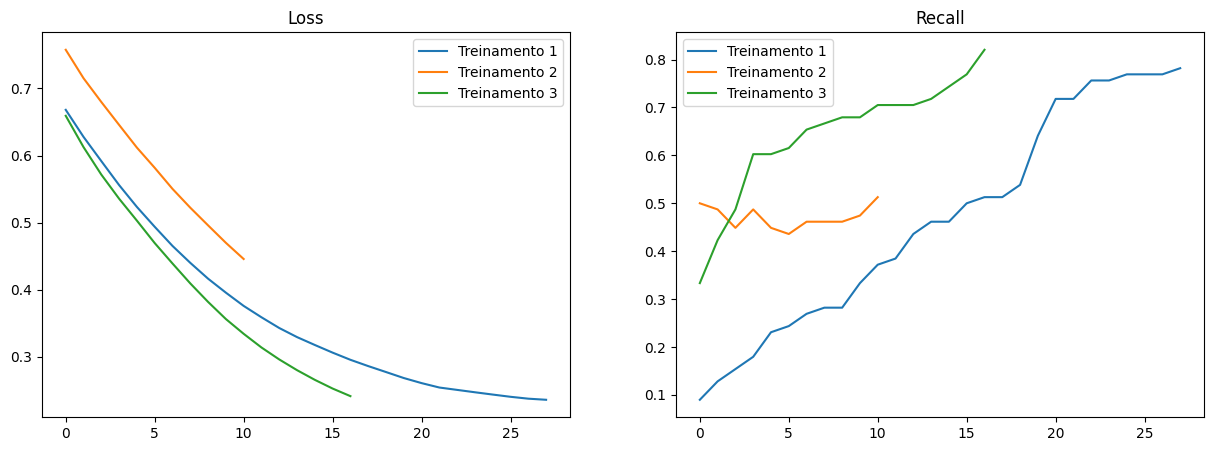

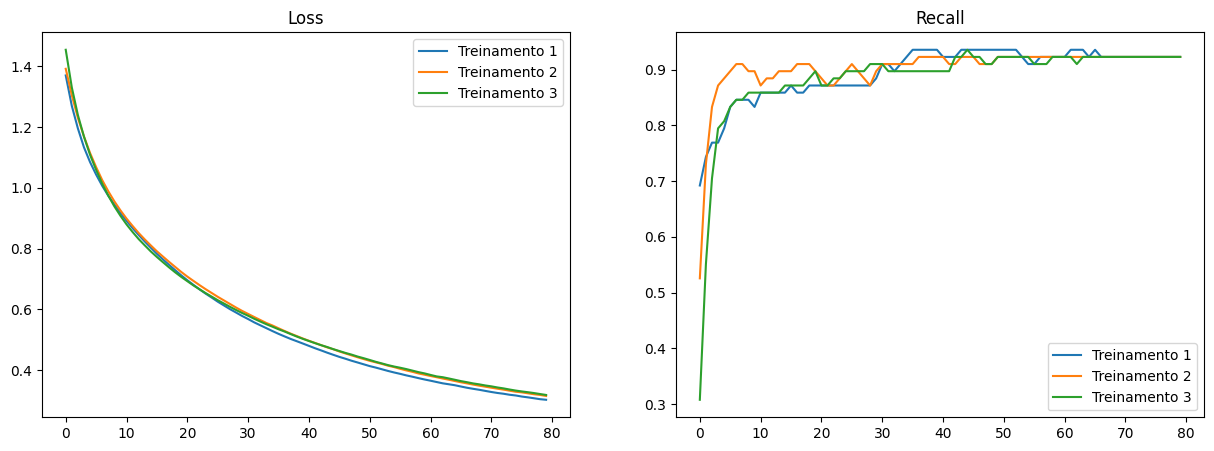

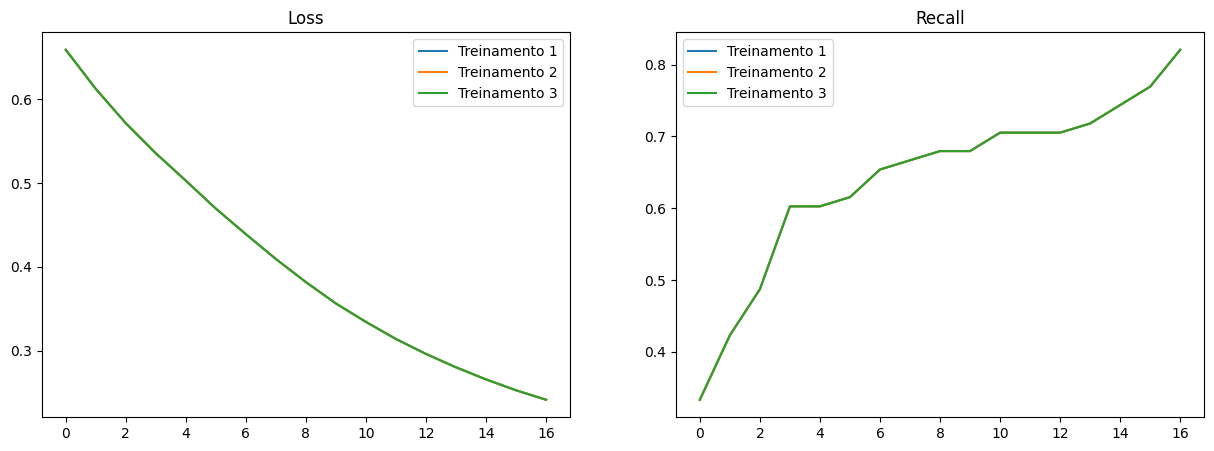

In [ ]:
# Iniciando a comparação entre os treinamentos de cada modelo


# primeira estrutura
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, mod in enumerate(historico[:3]):
  ax[0].plot(mod['estrutura1'].history['loss'], label=f'Treinamento {i+1}')
  ax[1].plot(mod['estrutura1'].history['Recall'], label=f'Treinamento {i+1}')
ax[0].set_title('Loss')
ax[1].set_title('Recall')
ax[0].legend()
ax[1].legend()

# # Segunda estrtura
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, mod in enumerate(historico[3:6]):
  ax[0].plot(mod['estrutura2'].history['loss'], label=f'Treinamento {i+1}')
  ax[1].plot(mod['estrutura2'].history['Recall'], label=f'Treinamento {i+1}')
ax[0].set_title('Loss')
ax[1].set_title('Recall')
ax[0].legend()
ax[1].legend()

# # terceira estrutura
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, mod in enumerate(historico[6:9]):
  ax[0].plot(mod['estrutura3'].history['loss'], label=f'Treinamento {i+1}')
  ax[1].plot(mod['estrutura3'].history['Recall'], label=f'Treinamento {i+1}')
ax[0].set_title('Loss')
ax[1].set_title('Recall')
ax[0].legend()
ax[1].legend()
plt.show()

In [ ]:
# Verificando a média e o desvio padrão dos resultados
df = pd.DataFrame(resultados)

# Tirando a média e desvio padrão dos modelos

df_final = df.groupby('Modelo').agg({
    'loss': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'tempo_treinamento': ['mean', 'std'],
    'Params': 'first'
}).reset_index()
df_final.columns = ['Modelo', 'loss_média', 'loss_std', 'recall_média', 'recall_std', 'tempo_médio', 'tempo_std', 'Params']
df_final



,Modelo,loss_média,loss_std,recall_média,recall_std,tempo_médio,tempo_std,Params
0,Tt_model_1,0.472164,0.221469,0.508772,0.160792,4.949726,1.590100,417
1,Tt_model_2,0.360153,0.009030,0.842105,0.000000,14.436220,0.295610,1489
2,Tt_model_3,0.635611,0.012767,0.824561,0.030387,18.315725,0.471243,13441


Para finalizar vou tirar o classification_report entre os modelos

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
y_pred_mod = model.predict(x_test)
y_pred_mod = np.array([1 if n > 0.5 else 0 for n in y_pred_mod])

# Experimento 2
y_pred_mod2 = model2.predict(x_test)
y_pred_mod2 = np.array([1 if n > 0.5 else 0 for n in y_pred_mod2])

# Experimento 3

y_pred_mod3 = model3.predict(x_test)
y_pred_mod3 = np.array([1 if n > 0.5 else 0 for n in y_pred_mod2])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [ ]:
# Experimento 1
print('-' * 25,'Experimento 1', '-'*25)
print(classification_report(y_pred_mod, y_test))
# Experimento 2
print('-' * 25,'Experimento 2', '-'*25)
print(classification_report(y_test, y_pred_mod2))
# Experimento 3
print('-' * 25,'Experimento 3', '-'*25)
print(classification_report(y_test, y_pred_mod3))

------------------------- Experimento 1 -------------------------
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        62
           1       0.68      0.87      0.76        15

    accuracy                           0.90        77
   macro avg       0.82      0.88      0.85        77
weighted avg       0.91      0.90      0.90        77

------------------------- Experimento 2 -------------------------
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        58
           1       1.00      0.84      0.91        19

    accuracy                           0.96        77
   macro avg       0.98      0.92      0.94        77
weighted avg       0.96      0.96      0.96        77

------------------------- Experimento 3 -------------------------
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        58
           1       1.00      0.84      

## Considerações finais:
* Desempenho dos modelos:
    
    O modelo Tt_model_1 (mais simples) apresentou o menor tempo médio de treinamento, mas teve o pior desempenho em recall.

    O modelo Tt_model_2 apresentou um equilíbrio entre desempenho e custo computacional, obtendo bom recall com aumento moderado de parâmetros.

    O modelo Tt_model_3 (mais complexo) alcançou o maior recall médio, porém com custo computacional elevado, tanto em número de parâmetros quanto em tempo de treinamento.

* Resultados:

    Pode se observar que aumentar o números de parâmetros trouxe um aumento no recall, mas comparando os 3 modelos o ganho não foi tão bom ao ponto de compensar o aumento computacional no terceiro modelo.
    O tempo de treinamento aumentou comforme a complexidade da rede aumentou.


* Final:
    Diante dos resultados, o modelo Tt_model_2 se mostrou a melhor escolha para este problema, combinando boa capacidade de generalização com um custo computacional aceitável.

* Sugestões para refinamento:

Explorar técnicas de regularização adicionais (como Dropout mais intensos ou Early Stopping).

Testar otimizações como batch normalization ou diferentes algoritmos de otimização (optimizers).

Avaliar a utilização de estratégias de aumento de dados (data augmentation) caso aplicável.